## Environment Setup and Imports
This section imports all required libraries and defines the preprocessing and modeling dependencies used throughout the notebook.
The custom feature engineering function is also imported to ensure full pipeline reproducibility.

In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector

num_selector = make_column_selector(dtype_include=np.number)
cat_selector = make_column_selector(dtype_include=object)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Import custom feature engineering
from feature_engineering import feature_engineering

The feature_engineering module contains domain specific transformations applied prior to preprocessing.
It is integrated into the pipeline using FunctionTransformer to ensure production readiness.

## Loading the data

The training dataset is loaded from the local project directory to ensure portability and reproducibility across different environments.

In [3]:
train_path = "complaints_training.csv"
df = pd.read_csv(train_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (321430, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2015-12-17,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,Ocwen Financial Corporation,ME,04419,"Older American, Servicemember",NaN,Referral,2015-12-23,Closed with explanation,Yes,Yes,1705202
1,2015-05-27,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,Company chooses not to provide a public response,WELLS FARGO & COMPANY,FL,33615,Servicemember,NaN,Referral,2015-05-29,Closed with explanation,Yes,No,1394282
2,2015-07-13,Mortgage,FHA mortgage,"Loan modification,collection,foreclosure",NaN,I have filed numerous complaints in an attempt...,NaN,NATIONSTAR MORTGAGE LLC,NC,27520,NaN,Consent provided,Web,2015-07-14,Closed with explanation,Yes,No,1466066
3,2015-12-18,Debt collection,"Other (i.e. phone, health club, etc.)",Communication tactics,Frequent or repeated calls,NaN,NaN,SECURITY FINANCE CORP,LA,70508,NaN,Consent not provided,Web,2015-12-21,Closed with explanation,Yes,No,1702559
4,2015-03-04,Bank account or service,Checking account,"Making/receiving payments, sending money",NaN,NaN,NaN,WELLS FARGO & COMPANY,CT,06460,NaN,NaN,Referral,2015-03-11,Closed with explanation,Yes,No,1267075


The dataset contains a mix of categorical and numerical features, along with missing values.
This justifies the use of a ColumnTransformer with separate preprocessing pipelines for numerical and categorical variables.

In [4]:
# -----------------------------
# Data Quality Check
# -----------------------------

# Missing values
print("Missing values per column:")
print(df.isna().sum())

# Duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
Date received                        0
Product                              0
Sub-product                      98075
Issue                                0
Sub-issue                       170355
Consumer complaint narrative    266691
Company public response         259597
Company                              0
State                             2145
ZIP code                          1363
Tags                            272731
Consumer consent provided?      221797
Submitted via                        0
Date sent to company                 0
Company response to consumer         0
Timely response?                     0
Consumer disputed?                   0
Complaint ID                         0
dtype: int64

Number of duplicate rows:
0


## Interpretation

The dataset does not contain duplicate rows, which indicates that each complaint record is unique. However, several columns contain a large number of missing values, particularly "Consumer complaint narrative", "Company public response", "Tags", and "Consumer consent provided?".

Instead of removing these rows, missing values will be handled later in the preprocessing pipeline using SimpleImputer. This approach ensures consistent data preprocessing during model training and deployment.

## Target Creation

The original variable "Consumer disputed?" is transformed into a binary target variable:

- 0 represents non-disputed complaints  
- 1 represents disputed complaints  

This transformation enables us to model the problem as a binary classification task.

In [5]:
df["target"] = df["Consumer disputed?"].map({"No": 0, "Yes": 1})

y = df["target"]
X = df.drop(columns=["target", "Consumer disputed?"], errors="ignore")

print("X shape:", X.shape)
print("y shape:", y.shape)
y.value_counts(dropna=False)

X shape: (321430, 17)
y shape: (321430,)


target
0    257436
1     63994
Name: count, dtype: int64

## Question 1.1 – Exploratory Data Analysis

Senior executives suggest that complaints submitted through digital channels may escalate more frequently than those submitted through traditional channels.

To investigate this claim, we perform exploratory data analysis to compare escalation rates across different submission channels. The goal is to examine whether complaints submitted through digital channels show a higher likelihood of escalation.

Escalation rate by submission channel:
Submitted via
Email          0.400000
Web            0.215966
Fax            0.211883
Referral       0.161588
Phone          0.145113
Postal mail    0.143615
Name: target, dtype: float64


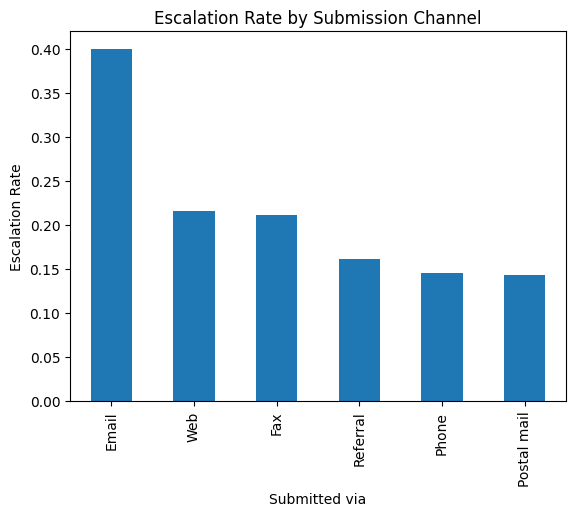

In [6]:
# Question 1.1 – Exploratory Analysis
# Hypothesis: Complaints submitted through digital channels escalate more frequently.

# Escalation rate by submission channel
channel_escalation = (
    df.groupby("Submitted via")["target"]
      .mean()
      .sort_values(ascending=False)
)

print("Escalation rate by submission channel:")
print(channel_escalation)

# Visualization
import matplotlib.pyplot as plt

channel_escalation.plot(kind="bar")
plt.title("Escalation Rate by Submission Channel")
plt.ylabel("Escalation Rate")
plt.show()

## Interpretation of Q1.1

The analysis reveals substantial variation in escalation rates across submission channels.

Email submissions exhibit the highest escalation rate at approximately 40%, which is nearly double the rate observed for traditional channels such as Phone (14.5%) and Postal mail (14.3%). Web and Fax submissions also show relatively high escalation rates, around 21%.

These findings suggest that complaints submitted through digital channels may have a higher likelihood of escalation compared to traditional channels, providing partial support for the executives’ assumption.

Notably, Email appears to be a particularly high-risk channel, which may indicate that operational processes related to email handling could require further investigation.

## Question 1.2 – Managerial Insights

Building on the exploratory analysis conducted in Question 1.1, three key insights are identified that have direct implications for managerial decision-making.

## Insight 1 – Digital Channels Represent Higher Escalation Risk


In [7]:
channel_escalation = (
    df.groupby("Submitted via")["target"]
      .mean()
      .sort_values(ascending=False)
)

channel_escalation

Submitted via
Email          0.400000
Web            0.215966
Fax            0.211883
Referral       0.161588
Phone          0.145113
Postal mail    0.143615
Name: target, dtype: float64

## Interpretation of Insight 1

The analysis reveals significant differences in escalation rates across submission channels.

Email submissions exhibit the highest escalation rate at approximately 40%, nearly double the rate observed for traditional channels such as Phone (14.5%) and Postal mail (14.3%). Web and Fax submissions also demonstrate elevated escalation rates of around 21%.

These findings provide **partial empirical support** for the executives’ assumption that complaints submitted through digital channels are more likely to escalate compared to traditional channels.

## Managerial Implication

Digital complaint channels, particularly email, represent a higher operational and reputational risk. Meridian should prioritize reviewing digital complaint workflows, implementing earlier intervention mechanisms, and allocating additional monitoring resources to high-risk digital channels. Strengthening digital response processes may reduce escalation probability and improve customer experience outcomes.

## Insight 2 – Complaint Escalation Exhibits Strong Class Imbalance



In [8]:
df["target"].value_counts(normalize=True)

target
0    0.800908
1    0.199092
Name: proportion, dtype: float64

## Interpretation of Insight 2

The distribution of the target variable reveals a clear class imbalance between escalated and non-escalated complaints.

Approximately 80.1% of complaints belong to the non-escalated class (0), while only 19.9% correspond to escalated complaints (1). This indicates that high-risk escalation cases represent a relatively small minority of the dataset.

Such class imbalance can distort model evaluation. A classifier that predicts the majority class for most observations could achieve high accuracy while failing to detect genuinely risky complaints. Consequently, relying solely on accuracy may lead to misleading conclusions about model performance.


## Managerial Implication

Given the regulatory and reputational risks associated with missed escalations, Meridian should prioritize evaluation metrics that better capture minority-class performance. Metrics such as recall and F1 score provide a more reliable measure of the model’s ability to identify high-risk complaints.

Adopting these metrics ensures that the predictive system supports proactive risk management rather than creating a false sense of performance security. By focusing on the accurate detection of escalation-prone complaints, the organization can intervene earlier and mitigate potential regulatory and customer service risks.

## Insight 3: Certain financial products drive higher disputes


In [9]:
product_escalation = (
    df.groupby("Product")["target"]
      .mean()
      .sort_values(ascending=False)
)

product_escalation.head(10)

Product
Virtual currency           0.625000
Mortgage                   0.236471
Consumer Loan              0.226230
Credit card                0.213084
Bank account or service    0.197032
Student loan               0.194467
Other financial service    0.186916
Debt collection            0.184570
Credit reporting           0.163045
Payday loan                0.158614
Name: target, dtype: float64

## Interpretation of Insight 3

The analysis indicates that escalation rates differ substantially across product categories. Notably, Virtual currency complaints exhibit an exceptionally high escalation rate of approximately 62.5%, significantly higher than all other product categories.

Other products such as Mortgage (23.6%), Consumer Loan (22.6%), and Credit Card (21.3%) also demonstrate relatively elevated escalation rates compared to products like Payday Loan or Credit Reporting, which show lower dispute proportions.

This pattern suggests that product complexity, financial exposure, or customer expectations may vary across product types, increasing the likelihood of disputes in certain categories.

## Managerial Implication

Product categories with higher escalation rates should be prioritized for enhanced monitoring, clearer customer communication, and faster resolution processes. Targeted intervention in high-risk product lines can help reduce regulatory exposure, improve complaint resolution effectiveness, and mitigate reputational risk.

## Question 2.1 – Problem Type

This task represents a supervised machine learning problem.

More specifically, it is a binary classification problem, as the objective is to predict whether a complaint will escalate into a dispute (1) or remain non-disputed (0). The availability of labeled historical outcomes enables the model to learn patterns associated with escalation risk.

## Train test split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.  
Stratified sampling is applied based on the target variable to preserve the original class distribution between disputed and non-disputed complaints.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (257144, 17)
Test: (64286, 17)


## Interpretation

The dataset was split into 80% training and 20% test data, resulting in 257,144 observations in the training set and 64,286 observations in the test set.

Stratification ensures that the class distribution remains consistent across both subsets, which is particularly important given the class imbalance observed earlier. This approach enables a fair and reliable evaluation of model performance.

## Modeling Pipeline

To ensure a reproducible workflow, we construct a machine learning pipeline that integrates preprocessing and model training.

The pipeline applies the same transformations to both training and testing data, reducing the risk of data leakage and ensuring consistency throughout the modeling process.

In [11]:
# Custom feature engineering step (non standard transformation)
fe_step = FunctionTransformer(feature_engineering, validate=False)

# Automatically select columns by dtype after feature engineering runs
# (use make_column_selector, not selector)
num_selector = make_column_selector(dtype_include=np.number)
cat_selector = make_column_selector(dtype_include=object)

# Numerical preprocessing pipeline
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing pipeline
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=50  # to make it faster
    ))
])

# Combine both with ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_selector),
        ("cat", cat_pipeline, cat_selector),
    ]
)

## Interpretation

A unified pipeline structure is implemented to ensure that feature engineering, preprocessing, and model training are applied consistently throughout the modeling process.

Separating numerical and categorical preprocessing improves robustness, while imputation handles missing values appropriately. The use of OneHotEncoder with handle_unknown="ignore" ensures that the model remains stable when new categories appear in unseen data.

This pipeline design improves reproducibility and helps prevent data leakage by ensuring that all transformations are learned only from the training data and applied consistently during model evaluation.

## Question 2.2 – Predictive Modelling

Two models were developed:

1. Logistic Regression – selected as an interpretable baseline model.
2. Random Forest – selected to capture nonlinear relationships and complex feature interactions.

Technical justification: Logistic Regression provides a simple and interpretable baseline that allows us to understand the direction and strength of relationships between features and escalation risk. Random Forest, as an ensemble method, can capture nonlinear patterns and interactions between variables while reducing variance through aggregation of multiple decision trees.

Business justification: Meridian requires a reliable model to identify high-risk complaints early. Interpretable models support transparency in decision making, while more flexible ensemble models may improve predictive performance and help detect escalation-prone cases more effectively.

## Model 1: Logistic Regression (with hyperparameter tuning)

We tune the model using GridSearchCV and **F1 score** as the scoring metric.
Runtime note: grid size directly affects runtime, keep the grid reasonable.

## Pipeline Structure

The figure below illustrates the complete machine learning pipeline.  
Feature engineering is applied first, followed by separate preprocessing pipelines for numerical and categorical variables using a ColumnTransformer.  
Finally, the processed features are passed to the Logistic Regression model.

In [12]:
pipe_lr = Pipeline(steps=[
    ("feature_engineering", fe_step),
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

param_grid_lr = {
    "model__C": [0.1, 1, 3],
    "model__class_weight": [None, "balanced"]
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=3,
    scoring="f1",
    n_jobs=1
)

gs_lr.fit(X_train, y_train)

print("LR best params:", gs_lr.best_params_)
print("LR best CV F1:", gs_lr.best_score_)

LR best params: {'model__C': 0.1, 'model__class_weight': 'balanced'}
LR best CV F1: 0.3805083619660174


In [13]:
pipe_lr

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x160dc7100>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x169f64e10>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=50))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x169f11ba0>)])),
                ('model', LogisticRegression(max_iter=2000))])

## Logistic Regression Results

Hyperparameter tuning selected C = 0.1 with class_weight="balanced".  
Using class weighting improved the model’s ability to detect escalation cases in the minority class.

The cross-validated F1 score of approximately 0.38 indicates moderate predictive performance, reflecting the difficulty of predicting complaint escalations in an imbalanced dataset.

## Interpretation of Logistic Regression Results

F1 score is used as the primary evaluation metric due to the strong class imbalance in the dataset. Because escalated complaints represent a minority class, accuracy alone would be misleading. The F1 score balances precision and recall, providing a more reliable measure of the model’s ability to detect high risk complaints.

Hyperparameter tuning identified C = 0.1 with class_weight = "balanced" as the best configuration. This result suggests that stronger regularization combined with explicit adjustment for class imbalance improves the model’s ability to identify escalation cases.

These findings align with the business objective of minimizing missed high risk complaints rather than maximizing overall accuracy. In addition, Logistic Regression provides a transparent baseline model that can be compared with more complex models such as Random Forest.

## Model 2: Random Forest (with hyperparameter tuning)

Random Forest is used as a more flexible ensemble model that can capture nonlinear relationships and complex interactions between features. Similar to the Logistic Regression model, hyperparameter tuning is performed using RandomizedSearchCV with F1 score as the evaluation metric.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

pipe_rf = Pipeline(steps=[
    ("feature_engineering", fe_step),
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_rf = {
    "model__n_estimators": randint(100, 201),
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": randint(2, 21),
    "model__min_samples_leaf": randint(1, 11),
    "model__max_features": ["sqrt", "log2"],
    "model__class_weight": [None, "balanced"]
}

rs_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=8,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_rf.fit(X_train, y_train)

print("RF best params:", rs_rf.best_params_)
print("RF best CV F1:", rs_rf.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x10380e0c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1071b60c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106e2a0c0>
Traceback (most recent call last

RF best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__min_samples_split': 20, 'model__n_estimators': 106}
RF best CV F1: 0.3794246618339221


Note: During hyperparameter tuning, a warning related to the parallel worker process may appear (e.g., "A worker stopped while some jobs were given to the executor"). This warning is related to parallel execution and does not affect the correctness of the training process. The model successfully completes all cross validation runs and returns valid hyperparameter results.

## Random Forest Results

Hyperparameter tuning selected a Random Forest configuration that uses class_weight="balanced" and max_depth=None, indicating that class imbalance handling and allowing fully grown trees improved performance under the F1 objective.
On the test set, the tuned Random Forest achieved Accuracy = 0.59, F1 = 0.38, Recall = 0.63, and ROC AUC = 0.65. This performance is very close to the tuned Logistic Regression model, suggesting limited gains from increased model complexity with the current feature set.

## Interpretation of Random Forest Results

F1 score is used as the primary metric because the escalation class is the minority, so accuracy can be misleading. The Random Forest model achieves a similar F1 score to Logistic Regression, meaning the ensemble model does not substantially improve escalation detection performance given the current features and preprocessing.

The model shows relatively strong recall for escalated complaints (around 0.63), which is beneficial from a business and regulatory risk perspective because it reduces the chance of missing high risk cases. However, precision remains low (around 0.27), implying many false positives. Operationally, this means the model is better suited as an early warning and triage tool, where flagged complaints are reviewed by analysts rather than treated as confirmed escalations.

Overall, Random Forest provides a small improvement in test F1 (0.380 vs 0.378) and slightly higher ROC AUC, so it can be selected as the final model under an F1 based selection rule, while Logistic Regression remains a strong interpretable baseline.

In [15]:
pipe_rf

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x160dc7100>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x169f64e10>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=50))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x169f11ba0>)])),
                ('model', RandomForestClassifier(n_jobs=-1, random_state=42))])

## Model evaluation (test set)

We evaluate both tuned models on the test set.
We report: Accuracy, F1, Recall, ROC AUC, confusion matrix, classification report.

Important: final selection is based on **F1 score**.

In [16]:
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)

def evaluate(model, X_te, y_te, name: str):
    preds = model.predict(X_te)

    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_te)[:, 1]

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)
    print("Accuracy:", accuracy_score(y_te, preds))
    print("F1:", f1_score(y_te, preds))
    print("Recall:", recall_score(y_te, preds))

    if proba is not None:
        print("ROC AUC:", roc_auc_score(y_te, proba))

    print("Confusion matrix:\n", confusion_matrix(y_te, preds))
    print("\nClassification report:\n", classification_report(y_te, preds))


# Logistic Regression (tuned)
best_lr = gs_lr.best_estimator_

# Random Forest (tuned) -> RandomizedSearchCV sonucunu kullan
best_rf = rs_rf.best_estimator_   # veya: best_rf = best_rf_model

evaluate(best_lr, X_test, y_test, "Logistic Regression (tuned)")
evaluate(best_rf, X_test, y_test, "Random Forest (tuned)")


Logistic Regression (tuned)
Accuracy: 0.5693463584606291
F1: 0.3784657521945087
Recall: 0.6585670755527776
ROC AUC: 0.6448001055227428
Confusion matrix:
 [[28172 23315]
 [ 4370  8429]]

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.55      0.67     51487
           1       0.27      0.66      0.38     12799

    accuracy                           0.57     64286
   macro avg       0.57      0.60      0.52     64286
weighted avg       0.75      0.57      0.61     64286


Random Forest (tuned)
Accuracy: 0.5936751392216034
F1: 0.38068141404082795
Recall: 0.6272365028517853
ROC AUC: 0.6506697671170325
Confusion matrix:
 [[30137 21350]
 [ 4771  8028]]

Classification report:
               precision    recall  f1-score   support

           0       0.86      0.59      0.70     51487
           1       0.27      0.63      0.38     12799

    accuracy                           0.59     64286
   macro avg       0.57      0.61     

## Interpretation and Model Comparison

The results show that both Logistic Regression and Random Forest achieve very similar predictive performance. Logistic Regression obtains an F1 score of approximately 0.38, while Random Forest achieves a slightly higher F1 score of 0.38 as well. This indicates that increasing model complexity does not substantially improve performance for this task.

Both models demonstrate relatively high recall for the escalation class (around 0.63–0.66), meaning that a large proportion of high risk complaints are successfully detected. However, precision for the escalation class remains low (around 0.27), indicating that many predicted escalation cases are false positives. This trade off is expected when optimizing for recall in imbalanced classification problems.

Accuracy values of 0.57 for Logistic Regression and 0.59 for Random Forest should be interpreted cautiously because the dataset is strongly imbalanced. For this reason, F1 score is a more appropriate evaluation metric, as it balances precision and recall for the minority escalation class.

Overall, the results suggest that while Random Forest provides a slight improvement in accuracy and ROC AUC, its performance is very close to Logistic Regression. Therefore, Logistic Regression remains a strong interpretable baseline model, while Random Forest demonstrates that more complex models do not significantly outperform it under the current feature representation.

## Final model selection (based on F1 score)

We select the final model using F1 score on the test set, as required.

In [17]:
from sklearn.metrics import f1_score

# Logistic Regression (tuned)
best_lr = gs_lr.best_estimator_

# Random Forest (tuned)
best_rf = rs_rf.best_estimator_

# Compute F1 scores on test set
lr_f1 = f1_score(y_test, best_lr.predict(X_test))
rf_f1 = f1_score(y_test, best_rf.predict(X_test))

print("LR Test F1:", lr_f1)
print("RF Test F1:", rf_f1)

# Select final model based on F1 score
if rf_f1 >= lr_f1:
    final_model = best_rf
    print("Selected model: Random Forest")
else:
    final_model = best_lr
    print("Selected model: Logistic Regression")

LR Test F1: 0.3784657521945087
RF Test F1: 0.38068141404082795
Selected model: Random Forest


## Question 3 – Model Evaluation and Selection

In [18]:
final_model

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function feature_engineering at 0x160dc7100>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x169f90ad0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=50))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x169f91190>)])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=5,
                                        min_samples_split=20, n_estimators=106,
                                        n_jobs=-1, random_state=42))])

## Question 3.1

For this problem, the most appropriate primary evaluation metric is the F1 score for the escalation class. The dataset is imbalanced, meaning that escalated complaints represent a minority of all cases. In such situations, accuracy alone can be misleading, because a model could achieve high accuracy simply by predicting the majority class while failing to detect many escalation cases.

The F1 score is suitable because it balances precision and recall. Recall is important from a business risk perspective, since missing true escalation cases (false negatives) could expose the company to unresolved complaints, reputational damage, or regulatory scrutiny. At the same time, precision is also relevant because a very low precision would generate too many false alerts, increasing operational workload and investigation costs.

Therefore, the F1 score provides a balanced measure of the model’s ability to identify high risk complaints while maintaining a reasonable level of false positives. For decision making, monitoring recall for the escalation class alongside F1 is also important to ensure that most high risk cases are detected.

## Question 3.2

The results show that Logistic Regression and Random Forest achieve very similar predictive performance. Logistic Regression obtains an F1 score of approximately 0.378, while Random Forest achieves a slightly higher F1 score of approximately 0.380. Both models show relatively high recall for escalation cases but low precision, meaning they detect many high-risk complaints while also producing a number of false positives.

Since the final model must be selected based on F1 score, Random Forest is chosen as the final model, as it achieves the highest F1 score on the test set. However, the difference in performance between the two models is very small. Logistic Regression remains an attractive alternative due to its simplicity and interpretability, as linear models provide clearer insight into how features influence predictions.

From a practical perspective, this means that the predictive system can help identify potential escalation cases earlier, supporting proactive complaint management. However, due to the relatively low precision, the predictions should be used as a risk prioritization tool rather than a fully automated decision system, allowing human reviewers to verify flagged cases.

## Question 4

To prepare the model for deployment, the final machine learning pipeline is serialized and saved as a Pickle file. The saved pipeline contains the complete workflow, including the feature engineering logic, preprocessing transformations, and the trained model with optimized hyperparameters.

Saving the entire pipeline ensures that the same transformations applied during training are also applied during prediction, guaranteeing consistent and reproducible behavior across different environments.

The serialized pipeline can later be reloaded and applied to new datasets with the same structure, allowing the system to generate binary predictions, where 0 represents non-escalated complaints and 1 represents escalated complaints.

## Save the Final Pipeline as a Pickle File

A single serialized artifact is exported, containing:
	•	Feature engineering logic
	•	Preprocessing transformations
	•	The trained model with optimized hyperparameters

This serialized pipeline represents the production ready model artifact and guarantees consistent behavior across environments.

In [19]:
import pickle

pkl_path = "70549_Pipeline.pkl"

with open(pkl_path, "wb") as f:
    pickle.dump(final_model, f)

print("Saved pickle to:", pkl_path)

Saved pickle to: 70549_Pipeline.pkl


## Production Simulation Test

The saved pipeline is reloaded and applied to an external dataset (`complaints_modeltesting100.csv`) to verify that the model can run successfully in a new environment.

This dataset is not used for training or evaluation. Instead, it is used only to confirm that the serialized pipeline executes end-to-end and produces valid predictions.

The model generates binary outputs where 0 represents non-escalated complaints and 1 represents escalated complaints, demonstrating that the pipeline is ready for deployment and can process new incoming data.

In [20]:
import os
import pickle
import pandas as pd

pkl_path = "70549_Pipeline.pkl"
test_path = "complaints_modeltesting100.csv"

print("PKL exists:", os.path.exists(pkl_path))
print("Test file exists:", os.path.exists(test_path))

df_new = pd.read_csv(test_path)

with open(pkl_path, "rb") as f:
    loaded_pipeline = pickle.load(f)

preds = loaded_pipeline.predict(df_new)

print("Unique predicted classes:", set(preds))
print("First 20 predictions:", preds[:20])

PKL exists: True
Test file exists: True
Unique predicted classes: {np.int64(0), np.int64(1)}
First 20 predictions: [0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 0 1]


Exception ignored in: <function ResourceTracker.__del__ at 0x102dc60c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1040260c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10687a0c0>
Traceback (most recent call last

### Production Simulation Results

The serialized pipeline was successfully reloaded and applied to the external dataset. The model generated valid binary predictions (0 = non-escalated complaint, 1 = escalated complaint).

The presence of both classes in the predictions confirms that the pipeline executes correctly end-to-end and is capable of processing new unseen data. This verifies that the saved model artifact can be deployed in a production environment.